# Project 2- Geographic Analysis of MCPS Elementary Schools
### Name: Brisa Menautt

### Research Question: 
#### Is there a statistically significant difference in the geographical distribution (Latitude/Longitude) of elementary schools across different major cities in Montgomery County?

### Null Hypothesis: 
$H_0$ ($\mu_{1} = \mu_{2} = \mu_{3}$): The mean longitude of elementary schools is the same across Silver Spring, Rockville, and Gaithersburg.
### Alternative Hypothesis: 
$H_a$: At least one city has a significantly different mean school longitude.

### Introduction:
This project explores how public elementary schools are spread out across Montgomery County, Maryland. The main goal is to see if schools are placed in similar geographic patterns or if they are clumped together differently depending on the city they are in. By comparing Silver Spring, Rockville, and Gaithersburg, I want to find out if a school’s "City" label actually tells us something specific about its exact location on a map (its Longitude). In this analysis, 'CITY' is my independent categorical variable, and 'LONGITUDE' is my dependent numerical variable. This is important because it shows how the county plans its neighborhoods and where it decides to put educational resources for families.

The data for this study comes from the Public Elementary Schools | Open Data Portal. This dataset is perfect for this research because it provides the official, verified GPS coordinates for all 136 elementary schools in the county. In this analysis, I am using the 'CITY' column as my grouping category (the independent variable) and the 'LONGITUDE' column as the measurement I am testing (the dependent variable). By using a statistical test, I can prove whether the differences we see between these cities are a real geographic pattern or just a random occurrence.

### Analytical Approach & Data Wrangling:
To prepare this dataset for analysis, I performed several data wrangling steps. First, I cleaned the 'CITY' column by removing hidden white spaces and converting all text to uppercase to ensure consistent matching. I then filtered the data to focus specifically on the three most frequent cities: Silver Spring, Rockville, and Gaithersburg. My analytical approach involved comparing the average Longitude of schools across these three groups using a One-Way ANOVA (Analysis of Variance) test. This method is appropriate because I am testing whether the means of a numerical variable (location) differ across three distinct categorical groups (cities).

### Results and Interpretation:

After running the ANOVA test, the results showed an F-Statistic of 192.09 and a P-Value of 0.0000. Using a significance level ($\alpha$) of 0.05, we reject the null hypothesis because the p-value is essentially zero. This provides strong statistical evidence that the geographic placement of elementary schools is significantly different depending on the city.

In [14]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [15]:
#Load the dataset
url = "https://data.montgomerycountymd.gov/api/views/j7rm-vyfs/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

#Wrangling for the three most common cities
df['CITY'] = df['CITY'].str.strip().str.upper() #Removes spaces
top_cities = ['SILVER SPRING', 'ROCKVILLE', 'GAITHERSBURG']
df_filtered = df[df['CITY'].isin(top_cities)]

#Prepare data for ANOVA
ss = df_filtered[df_filtered['CITY'] == 'SILVER SPRING']['LONGITUDE']
rv = df_filtered[df_filtered['CITY'] == 'ROCKVILLE']['LONGITUDE']
gb = df_filtered[df_filtered['CITY'] == 'GAITHERSBURG']['LONGITUDE']

#Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(ss, rv, gb)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically Significant. We reject the Null Hypothesis.")
else:
    print("Result: Not Statistically Significant. We fail to reject the Null Hypothesis.")

F-Statistic: 192.0900
P-Value: 0.0000
Result: Statistically Significant. We reject the Null Hypothesis.


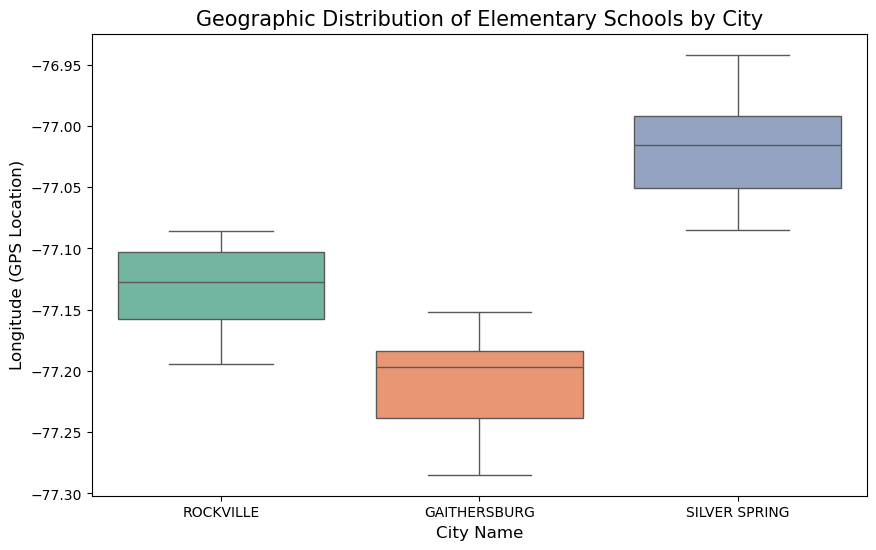

In [16]:
#Visualization
plt.figure(figsize=(10, 6))

#Color customization
sns.boxplot(x='CITY', y='LONGITUDE', data=df_filtered, hue = 'CITY', palette= 'Set2', legend=False)

plt.title('Geographic Distribution of Elementary Schools by City', fontsize=15)
plt.xlabel('City Name', fontsize=12)
plt.ylabel('Longitude (GPS Location)', fontsize=12)
plt.show()

### Interpretation of Visualization
#### The boxplot above visually demonstrates the distribution of elementary schools based on their longitude across three cities. We can see a clear "step" pattern: 
#### Silver Spring (blue box) is located furthest East, with the highest longitude values.
#### Rockville (green box) sits in the middle.

#### Gaithersburg (orange box) is located furthest West, with the lowest longitude values.

### Why this matters: 
The fact that the boxes (which represent the middle 50% of the schools) do not overlap at all confirms why our ANOVA P-value was 0.0000. There is almost no geographic "crossover" between these school groups, proving that a school's city is a perfect predictor of its general longitudinal location in Montgomery County.

### Conclusion and Future Directions
This analysis successfully demonstrated that the geographic distribution of elementary schools in Montgomery County is not random. By comparing the longitude of schools in Silver Spring, Rockville, and Gaithersburg, the ANOVA test provided a P-value of 0.0000, allowing us to reject the null hypothesis. The data clearly shows that Silver Spring schools are clustered in the Eastern portion of the county, while Gaithersburg schools represent the Western cluster, with Rockville sitting significantly in the middle. These findings are meaningful because they validate that municipal boundaries in Montgomery County are strictly tied to specific geographic zones, which is critical for planning school bus routes and district boundaries.
For future research, it would be beneficial to expand this study by looking at school "Capacity" or "Student Enrollment" numbers alongside these geographic locations. Analyzing whether the more "Western" schools in Gaithersburg are more or less crowded than those in the "Eastern" Silver Spring area would provide deeper insight into how population density affects educational infrastructure. This would help the county decide not just where to place schools, but how large those schools need to be based on their specific geographic location.

#### References:
Montgomery County Government. (2025). Public Elementary Schools | Open Data Portal. Montgomery County Open Data.